# Predictive Maintenance & Resource Optimization for Global Assets 

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
import warnings
warnings.filterwarnings('ignore')

df_raw = pd.read_csv(r"C:\DA Projects\predictive_maintence\predictive_maintenance.csv")

print("Shape :",df_raw.shape)
print("\n column names : ",df_raw.columns.tolist())
print("\n first 5 rows :")
df_raw.head()

Shape : (10000, 10)

 column names :  ['UDI', 'Product ID', 'Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Target', 'Failure Type']

 first 5 rows :


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,No Failure
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,No Failure
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,No Failure
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,No Failure
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,No Failure


In [19]:
print("========DATA TYPES============")
print(df_raw.dtypes)

print("\n========NULL VALUES===========")
print(df_raw.isnull().sum())

print("\n=======DUPLICATES=============")
print("Duplicate rows :", df_raw.duplicated().sum())

print("\n====CLASS DISTRIBUTION (Failure)====")
print(df_raw['Target'].value_counts())

print("\n===FAILURE TYPES ===")
print(df_raw['Failure Type'].value_counts())

print("\n ===DESCRIPTIVE STATS ===")
df_raw.describe()

========DATA TYPES============
UDI                          int64
Product ID                  object
Type                        object
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Target                       int64
Failure Type                object
dtype: object

========NULL VALUES===========
UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Target                     0
Failure Type               0
dtype: int64

=======DUPLICATES=============
Duplicate rows : 0

====CLASS DISTRIBUTION (Failure)====
Target
0    9661
1     339
Name: count, dtype: int64

===FAILURE TYPES ===
Failure Type
No Failure                  9652
Heat Dissipation Failure     112
Power Failure              

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000


In [20]:
df = df_raw.copy()

# ── 1. Check exact column names first
print("ORIGINAL columns:", df.columns.tolist())

# ── 2. Rename directly from original names → clean names
df.rename(columns={
    'UDI'                       : 'udi',
    'Product ID'                : 'product_id',
    'Type'                      : 'type',
    'Air temperature [K]'       : 'air_temp_k',
    'Process temperature [K]'   : 'process_temp_k',
    'Rotational speed [rpm]'    : 'rotational_speed',
    'Torque [Nm]'               : 'torque',
    'Tool wear [min]'           : 'tool_wear',
    'Target'                    : 'target',
    'Failure Type'              : 'failure_type'
}, inplace=True)

print("RENAMED columns:", df.columns.tolist())

# ── 3. Drop UDI
df.drop(columns=['udi'], inplace=True)

# ── 4. Fix data types (now using correct clean names)
df['product_id']   = df['product_id'].astype(str)
df['type']         = df['type'].astype('category')
df['failure_type'] = df['failure_type'].astype('category')
df['target']       = df['target'].astype(int)

# ── 5. Remove duplicates
before = len(df)
df.drop_duplicates(inplace=True)
print(f"Duplicates removed: {before - len(df)}")

# ── 6. Outlier capping via IQR
sensor_cols = ['air_temp_k', 'process_temp_k', 'rotational_speed', 'torque', 'tool_wear']

outlier_report = {}
for col in sensor_cols:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)].shape[0]
    outlier_report[col] = outliers
    df[col] = df[col].clip(lower=lower, upper=upper)

print("\nOutliers capped per column:")
for k, v in outlier_report.items():
    print(f"  {k}: {v} rows capped")

print("\nFinal dtypes:\n", df.dtypes)

ORIGINAL columns: ['UDI', 'Product ID', 'Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Target', 'Failure Type']
RENAMED columns: ['udi', 'product_id', 'type', 'air_temp_k', 'process_temp_k', 'rotational_speed', 'torque', 'tool_wear', 'target', 'failure_type']
Duplicates removed: 0

Outliers capped per column:
  air_temp_k: 0 rows capped
  process_temp_k: 0 rows capped
  rotational_speed: 418 rows capped
  torque: 69 rows capped
  tool_wear: 0 rows capped

Final dtypes:
 product_id            object
type                category
air_temp_k           float64
process_temp_k       float64
rotational_speed     float64
torque               float64
tool_wear              int64
target                 int64
failure_type        category
dtype: object


In [21]:
# feature engineering

# temp delta (process vs air) - thermal stress indicator
df['temp_delta'] = df['process_temp_k'] - df['air_temp_k']

# power approximation : torque * rotational speed 
df['power_watts'] = df['torque'] * (df['rotational_speed'] * 2 * np.pi /60)

# tool wear ratio 
df['tool_wear_ratio'] =df['tool_wear'] / df['tool_wear'].max()

# convert kelvin to celsius
df['air_temp_c'] = df['air_temp_k'] - 273.15
df['process_temp_c'] = df['process_temp_k'] - 273.15

# assign simulated regiosn
# the dataset has no geographhy so we assign regions based on prodct id prefic
region_map = {'L': 'Asia-Pacific','M':'Europe','H':'North americ'}
df['region'] = df['type'].astype(str).map(region_map)

print("new features added :")
print(df[['temp_delta','power_watts','tool_wear_ratio','air_temp_c','process_temp_c','region']].head())


new features added :
   temp_delta  power_watts  tool_wear_ratio  air_temp_c  process_temp_c  \
0        10.5  6951.590560         0.000000       24.95           35.45   
1        10.5  6826.722724         0.011858       25.05           35.55   
2        10.4  7749.387543         0.019763       24.95           35.35   
3        10.4  5927.504659         0.027668       25.05           35.45   
4        10.5  5897.816608         0.035573       25.05           35.55   

         region  
0        Europe  
1  Asia-Pacific  
2  Asia-Pacific  
3  Asia-Pacific  
4  Asia-Pacific  


In [22]:
# export clean data
import os
os.makedirs("C:\DA Projects\predictive_maintence\clean", exist_ok=True)

df.to_csv("C:\DA Projects\predictive_maintence\clean\predictive_maintence_clean.csv", index=False)
print(f"clean dataset saved : {df.shape[0]} rows * {df.shape[1]} columns")
print("\n final columns: ")
print(df.columns.tolist())

clean dataset saved : 10000 rows * 15 columns

 final columns: 
['product_id', 'type', 'air_temp_k', 'process_temp_k', 'rotational_speed', 'torque', 'tool_wear', 'target', 'failure_type', 'temp_delta', 'power_watts', 'tool_wear_ratio', 'air_temp_c', 'process_temp_c', 'region']


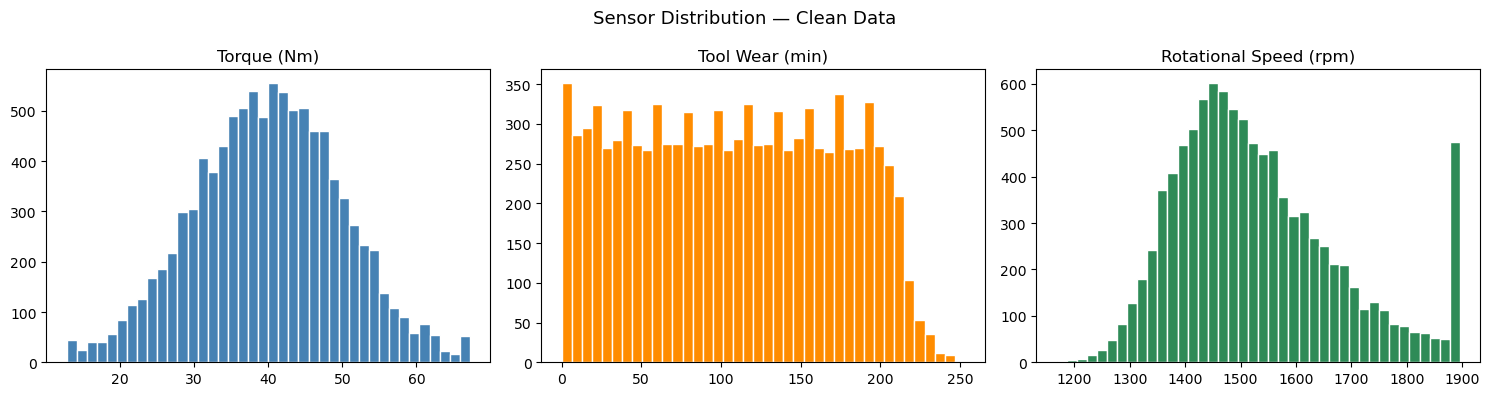

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Sensor Distribution — Clean Data', fontsize=13)

axes[0].hist(df['torque'],          bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Torque (Nm)')

axes[1].hist(df['tool_wear'],       bins=40, color='darkorange', edgecolor='white')
axes[1].set_title('Tool Wear (min)')

axes[2].hist(df['rotational_speed'],bins=40, color='seagreen',  edgecolor='white')
axes[2].set_title('Rotational Speed (rpm)')

plt.tight_layout()
plt.savefig('C:\DA Projects\predictive_maintence\clean\eda_sensor_distributions.png', dpi=150)
plt.show()

# Risk Scoring Engine + matplotlib charts


In [24]:
# load the clean data and sql exports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import os

In [25]:
# load cleqned dataset
df = pd.read_csv("C:\DA Projects\predictive_maintence\clean\predictive_maintence_clean.csv")

# sql exports
df_failure_rate = pd.read_csv("C:/DA Projects/predictive_maintence/exports/failure_rate_by_region.csv")
df_leg_lead = pd.read_csv("C:/DA Projects/predictive_maintence/exports/leg_led_wear_gaps.csv")
df_self_join = pd.read_csv("C:/DA Projects/predictive_maintence/exports/self_join_repear_failures(1).csv")
df_risk_ranking = pd.read_csv("C:/DA Projects/predictive_maintence/exports/regional_risk_ranking.csv")
df_at_risk = pd.read_csv("C:/DA Projects/predictive_maintence/exports/at_risk_machines30day.csv")

print("main data set shape :", df.shape)
print("At- risk machines :", df_at_risk.shape)
df.head()

main data set shape : (10000, 15)
At- risk machines : (500, 12)


,product_id,type,air_temp_k,process_temp_k,rotational_speed,torque,tool_wear,target,failure_type,temp_delta,power_watts,tool_wear_ratio,air_temp_c,process_temp_c,region
0,M14860,M,298.1,308.6,1551.0,42.8,0,0,No Failure,10.5,6951.590560,0.000000,24.95,35.45,Europe
1,L47181,L,298.2,308.7,1408.0,46.3,3,0,No Failure,10.5,6826.722724,0.011858,25.05,35.55,Asia-Pacific
2,L47182,L,298.1,308.5,1498.0,49.4,5,0,No Failure,10.4,7749.387543,0.019763,24.95,35.35,Asia-Pacific
3,L47183,L,298.2,308.6,1433.0,39.5,7,0,No Failure,10.4,5927.504659,0.027668,25.05,35.45,Asia-Pacific
4,L47184,L,298.2,308.7,1408.0,40.0,9,0,No Failure,10.5,5897.816608,0.035573,25.05,35.55,Asia-Pacific


In [26]:
# multi condition risk scoring engine
def calculate_risk_score(row):
    score =0

    # sesor threshold scoring
    if row['tool_wear_ratio'] > 0.85:
        score += 40
    elif row['tool_wear_ratio'] > 0.65:
        score += 25
    elif row['tool_wear_ratio'] > 0.45:
        score += 10

    if row['torque'] > 60:
        score += 25
    elif row['torque'] > 45:
        score += 15
    elif row['torque'] > 35:
        score += 5

    if row['temp_delta'] > 12:
        score += 20
    elif row['temp_delta'] >10:
        score += 10

    if row['type'] == 'L':
        score += 5
    elif row['type'] == 'M':
        score += 3

    return score


def assign_risk_label(score):
    if score >= 60:  return 'Critical'
    elif score >=40: return 'High'
    elif score >= 20: return 'Medium'
    else:  return 'Low'

def assign_risk_color(label):
    return {
        'Critical' : 'Red',
        'High'     : 'Orange',
        'Medium'   : 'Blue',
        'Low'      : 'Green'
    }[label]


# apply scoring
df['risk_score'] = df.apply(calculate_risk_score, axis = 1)
df['risk_label'] = df['risk_score'].apply(assign_risk_label)
df['risk_color']= df['risk_label'].apply(assign_risk_color)

print("Risk label distribution: ")
print(df['risk_label'].value_counts())
print("\n Avg risk score: ", round(df['risk_score'].mean(), 2))


Risk label distribution: 
risk_label
Medium      4320
Low         3996
High        1585
Critical      99
Name: count, dtype: int64

 Avg risk score:  23.84


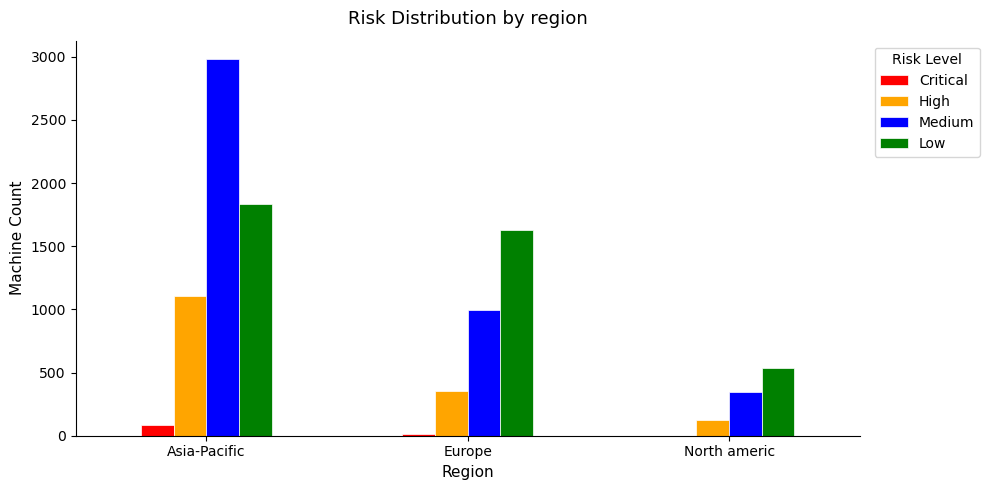

In [27]:
# chart 1: risk label distribution by region

fig, ax = plt.subplots(figsize=(10,5))
risk_order = ['Critical', 'High', 'Medium', 'Low']
colors = ['Red' , 'Orange','Blue','Green']

pivot = (df.groupby(['region','risk_label'])
         .size()
         .unstack(fill_value=0)
         .reindex(columns = risk_order, fill_value=0))
pivot.plot(kind='bar', ax=ax, color=colors, edgecolor='white',linewidth=0.5)

ax.set_title('Risk Distribution by region', fontsize=13, pad=12)
ax.set_xlabel('Region',fontsize=11)
ax.set_ylabel('Machine Count', fontsize=11)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title='Risk Level', bbox_to_anchor=(1.01,1), loc='upper left')
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
os.makedirs("C:/DA Projects/predictive_maintence/charts", exist_ok=True)
plt.savefig("C:/DA Projects/predictive_maintence/charts/risk_by_region.png",dpi=150)
plt.show()

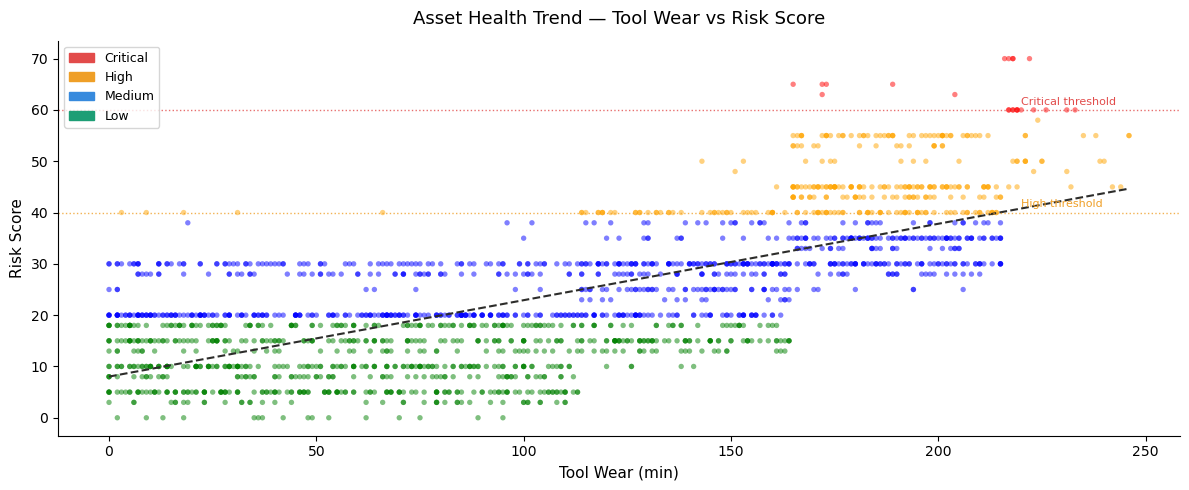

In [28]:
fig, ax = plt.subplots(figsize=(12, 5))

# Sample 2000 points for clarity
sample = df.sample(2000, random_state=42).sort_values('tool_wear')

ax.scatter(
    sample['tool_wear'],
    sample['risk_score'],
    c=sample['risk_color'],
    alpha=0.5,
    s=15,
    edgecolors='none'
)

# Trend line
z = np.polyfit(sample['tool_wear'], sample['risk_score'], 1)
p = np.poly1d(z)
ax.plot(
    sorted(sample['tool_wear']),
    p(sorted(sample['tool_wear'])),
    color='#2C2C2A', linewidth=1.5, linestyle='--', label='Trend'
)

# Threshold lines
ax.axhline(y=60, color='#E24B4A', linewidth=1, linestyle=':', alpha=0.8)
ax.axhline(y=40, color='#EF9F27', linewidth=1, linestyle=':', alpha=0.8)
ax.text(220, 61, 'Critical threshold', fontsize=8, color='#E24B4A')
ax.text(220, 41, 'High threshold',     fontsize=8, color='#EF9F27')

patches = [
    mpatches.Patch(color='#E24B4A', label='Critical'),
    mpatches.Patch(color='#EF9F27', label='High'),
    mpatches.Patch(color='#378ADD', label='Medium'),
    mpatches.Patch(color='#1D9E75', label='Low'),
]
ax.legend(handles=patches, loc='upper left', fontsize=9)
ax.set_title('Asset Health Trend — Tool Wear vs Risk Score', fontsize=13, pad=12)
ax.set_xlabel('Tool Wear (min)', fontsize=11)
ax.set_ylabel('Risk Score', fontsize=11)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('C:/DA Projects/predictive_maintence/charts/02_asset_health_trend.png', dpi=150)
plt.show()

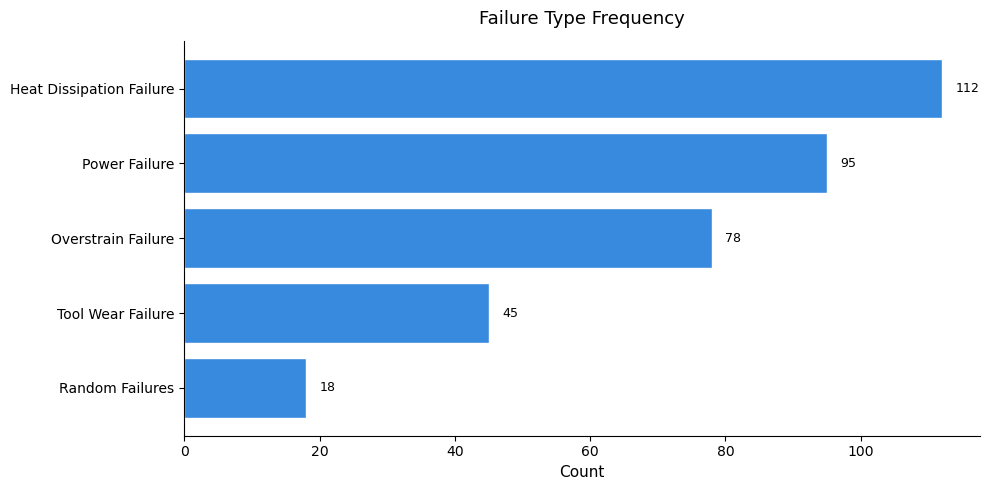

In [31]:
fig, ax = plt.subplots(figsize=(10, 5))

failure_counts = (df[df['failure_type'] != 'No Failure']
                  .groupby('failure_type')
                  .size()
                  .sort_values(ascending=True))

bars = ax.barh(
    failure_counts.index,
    failure_counts.values,
    color='#378ADD',
    edgecolor='white'
)

# Value labels
for bar, val in zip(bars, failure_counts.values):
    ax.text(val + 2, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=9)

ax.set_title('Failure Type Frequency', fontsize=13, pad=12)
ax.set_xlabel('Count', fontsize=11)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('C:/DA Projects/predictive_maintence/charts/03_failure_type_breakdown.png', dpi=150)
plt.show()